In [5]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [6]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATA_FILE = DATA_DIR / "dataSet_withFeatures.csv"
LABEL_FILE = DATA_DIR / "dataSet_withFeatures_labels.csv"

data = pd.read_csv(DATA_FILE, header=None)
labels = pd.read_csv(LABEL_FILE, header=None).iloc[:, 0]

print("Data:", data.shape)
print("Labels:", labels.shape)

Data: (5990, 448)
Labels: (5990,)


In [7]:
X = data.iloc[:, :447].copy()
y = labels.astype(str).str.strip().copy()

print("X:", X.shape)
print("y:", y.shape)

X: (5990, 447)
y: (5990,)


In [8]:
X_tactile = X.iloc[:, :414].to_numpy(dtype=np.float32)
X_features = X.iloc[:, 414:447].to_numpy(dtype=np.float32)

print("Tactile:", X_tactile.shape)
print("Features:", X_features.shape)

Tactile: (5990, 414)
Features: (5990, 33)


In [9]:
class_names = {
    "asphalt": 0,
    "cork": 1,
    "grass": 2,
    "gravel": 3,
    "lab": 4,
    "laminate_wood": 5,
    "pebble": 6,
    "sand": 7
}
y_encoded = y.map(class_names)

print(y_encoded.head())
print("\nMissing encoded labels:", y_encoded.isna().sum())

0    0
1    0
2    0
3    0
4    0
Name: 0, dtype: int64

Missing encoded labels: 0


In [10]:
print(
    pd.DataFrame({
        "terrain": y,
        "encoded": y_encoded
    }).drop_duplicates().sort_values("encoded")
)

            terrain  encoded
0           asphalt        0
404            cork        1
1136          grass        2
1837         gravel        3
2324            lab        4
2725  laminate_wood        5
3095         pebble        6
3820           sand        7


In [11]:
X_tactile_train, X_tactile_temp, \
X_features_train, X_features_temp, \
y_train, y_temp = train_test_split(
    X_tactile,
    X_features,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

In [12]:
X_tactile_val, X_tactile_test, \
X_features_val, X_features_test, \
y_val, y_test = train_test_split(
    X_tactile_temp,
    X_features_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [13]:
X_tactile_train = X_tactile_train.reshape(-1, 6, 69)
X_tactile_val = X_tactile_val.reshape(-1, 6, 69)
X_tactile_test = X_tactile_test.reshape(-1, 6, 69)

print(X_tactile_train.shape)

(4193, 6, 69)


In [14]:
tactile_mean = X_tactile_train.mean(axis=(0, 2), keepdims=True)
tactile_std = X_tactile_train.std(axis=(0, 2), keepdims=True)

print("Mean shape:", tactile_mean.shape)
print("Std shape:", tactile_std.shape)

Mean shape: (1, 6, 1)
Std shape: (1, 6, 1)


In [15]:
X_tactile_train = (
    X_tactile_train - tactile_mean
) / tactile_std

X_tactile_val = (
    X_tactile_val - tactile_mean
) / tactile_std

X_tactile_test = (
    X_tactile_test - tactile_mean
) / tactile_std

print("Train mean:", X_tactile_train.mean())
print("Train std:", X_tactile_train.std())

Train mean: -2.3065278e-08
Train std: 1.0


In [16]:
y_train = y_train.to_numpy(dtype=np.int64)
y_val = y_val.to_numpy(dtype=np.int64)
y_test = y_test.to_numpy(dtype=np.int64)

In [17]:
print("Training features:", X_features_train.shape)
print("Validation features:", X_features_val.shape)
print("Test features:", X_features_test.shape)

print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Training features: (4193, 33)
Validation features: (898, 33)
Test features: (899, 33)
Training labels: (4193,)
Validation labels: (898,)
Test labels: (899,)


In [18]:
svm_33 = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_33.fit(
    X_features_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [19]:
y_val_pred = svm_33.predict(X_features_val)

val_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Accuracy: 0.4176
Validation Accuracy: 41.76%


In [20]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001]
}

In [21]:
grid_search = GridSearchCV(
    estimator=SVC(
        kernel="rbf",
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_features_train,
    y_train
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom 

In [22]:
print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best Cross-Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")
print(f"{grid_search.best_score_ * 100:.2f}%")

Best Parameters:
{'C': 100, 'gamma': 'scale'}

Best Cross-Validation Accuracy:
0.5504
55.04%


In [23]:
best_svm_33 = grid_search.best_estimator_

y_val_pred = best_svm_33.predict(
    X_features_val
)

val_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Accuracy: 0.5969
Validation Accuracy: 59.69%


In [24]:
print("\nValidation Classification Report:\n")

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=class_names,
        digits=4
    )
)


Validation Classification Report:

               precision    recall  f1-score   support

      asphalt     0.5440    0.5714    0.5574       119
         cork     0.4476    0.4273    0.4372       110
        grass     0.6481    0.6667    0.6573       105
       gravel     0.5435    0.4587    0.4975       109
          lab     0.5175    0.6379    0.5714       116
laminate_wood     0.6533    0.4224    0.5131       116
       pebble     0.5873    0.6789    0.6298       109
         sand     0.8387    0.9123    0.8739       114

     accuracy                         0.5969       898
    macro avg     0.5975    0.5970    0.5922       898
 weighted avg     0.5977    0.5969    0.5921       898



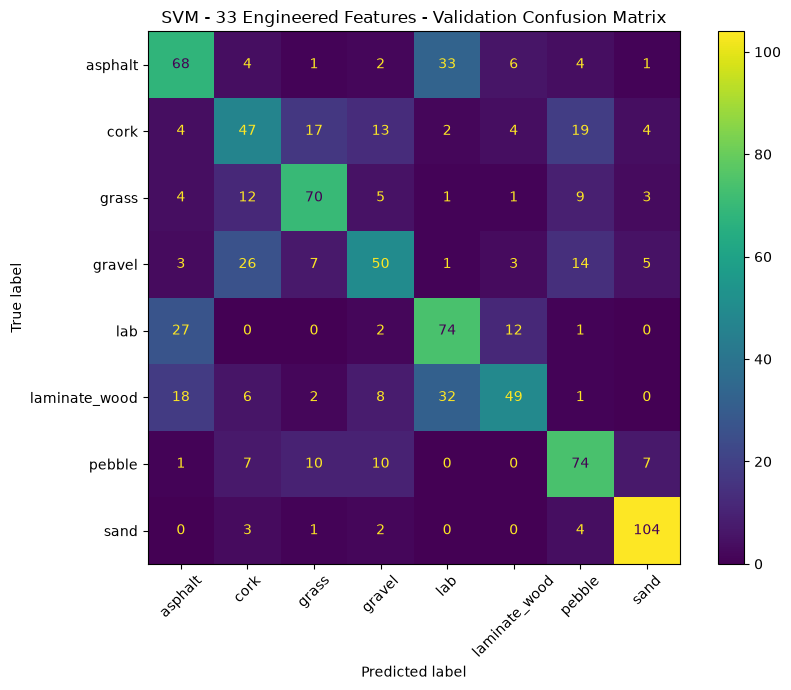

In [26]:
cm_val = confusion_matrix(
    y_val,
    y_val_pred
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

ax.set_title(
    "SVM - 33 Engineered Features - Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [36]:
#test predictions

best_svm_33 = grid_search.best_estimator_

y_test_pred = best_svm_33.predict(
    X_features_test
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.5484
Test Accuracy: 54.84%


In [37]:
print("SVM - 33 Engineered Features - Test Classification Report\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)

SVM - 33 Engineered Features - Test Classification Report

               precision    recall  f1-score   support

      asphalt     0.4538    0.4917    0.4720       120
         cork     0.3204    0.3000    0.3099       110
        grass     0.6559    0.5810    0.6162       105
       gravel     0.5263    0.4587    0.4902       109
          lab     0.4504    0.5043    0.4758       117
laminate_wood     0.6196    0.4914    0.5481       116
       pebble     0.5259    0.6574    0.5844       108
         sand     0.8583    0.9035    0.8803       114

     accuracy                         0.5484       899
    macro avg     0.5513    0.5485    0.5471       899
 weighted avg     0.5508    0.5484    0.5468       899



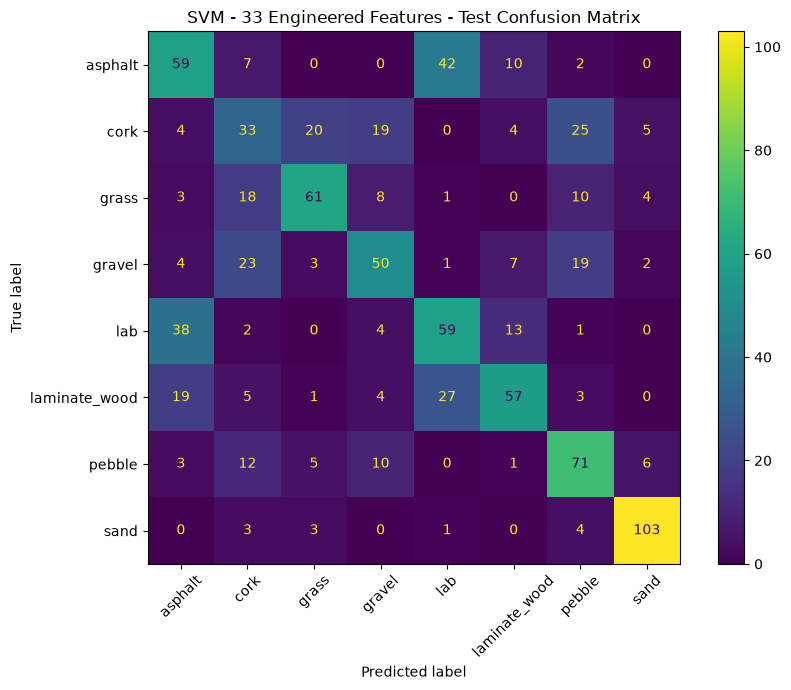

In [38]:
cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

ax.set_title(
    "SVM - 33 Engineered Features - Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [40]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)

               precision    recall  f1-score   support

      asphalt     0.4538    0.4917    0.4720       120
         cork     0.3204    0.3000    0.3099       110
        grass     0.6559    0.5810    0.6162       105
       gravel     0.5263    0.4587    0.4902       109
          lab     0.4504    0.5043    0.4758       117
laminate_wood     0.6196    0.4914    0.5481       116
       pebble     0.5259    0.6574    0.5844       108
         sand     0.8583    0.9035    0.8803       114

     accuracy                         0.5484       899
    macro avg     0.5513    0.5485    0.5471       899
 weighted avg     0.5508    0.5484    0.5468       899



In [ ]:
y_test_pred = best_svm_33.predict(X_svm_test)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")